<a href="https://colab.research.google.com/github/SaidCondoriRomero/SiS420_Inteligencia_Artificial/blob/main/Laboratorios/Laboratorio_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Condori Romero Said - Ing. Sistemas
## Laboratorio 2

# Origen del Dataset (Online Video Characteristics and Transcoding Time)
Página de obtención  
El dataset fue descargado desde el Repositorio UCI de Machine Learning en la siguiente URL:  
https://archive.ics.uci.edu/dataset/335/online+video+characteristics+and+transcoding+time+dataset  

Cada fila corresponde a un experimento de transcodificación de video realizado sobre un procesador Intel i7. Se tomaron videos de YouTube y se transcodificaron a distintos formatos usando la herramienta `ffmpeg`.

# Objetivo
Es estudiar el Dataset si es posible predecir el tiempo de transcodificación de videos (variable `utime`) a partir de las características del video de entrada y salida, usando tres métodos: regresión lineal multivariable, regresión polinómica y cálculo por la ecuación de la normal. Esto nos permite estimar el tiempo de procesamiento en segundos que tomará una tarea, optimizando así los recursos del sistema y tratar de predecir cuánto tiempo tarda ese proceso.

## Dimensiones del Dataset
Cantidad de Ejemplos ($m = 68784$)  
Cantidad de Características ($n = 22$)
### Variables del dataset
| Grupo | Variables | Descripción |
|-------|-----------|-------------|
| Video entrada | `duration`, `width`, `height`, `bitrate`, `framerate` | Características del video original |
| Frames | `i`, `p`, `b`, `frames` | Número de cada tipo de frame |
| Tamaños | `i_size`, `p_size`, `b_size`, `size` | Tamaño en bytes de cada tipo de frame |
| Video salida | `o_bitrate`, `o_framerate`, `o_width`, `o_height` | Parámetros del video transcodificado |
| Codecs | `codec`, `o_codec` | Estándar de codificación (mpeg4, h264, vp8, flv) |
| Recursos | `umem` | Memoria total asignada al codec |
| **Objetivo** | `utime` | Tiempo total de transcodificación (segundos) |


In [27]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [28]:
# Utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Manejo de datos tabulares
import pandas as pd

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

## Carga de Datos y Exploración Inicial

### Carga con pandas


In [29]:
ruta = '/content/gdrive/MyDrive/SIS420 Condori Romero Said/datasets/transcoding_mesurment.tsv'

# Cargar con pandas (archivo TSV separado por tabulaciones)
df = pd.read_csv(ruta, sep='\t')

print('Dimensiones del dataset (original):', df.shape)
print('Valores nulos:', df.isnull().sum().sum())
print()
print(df.head(10))

Dimensiones del dataset (original): (68784, 22)
Valores nulos: 0

            id   duration  codec  width  height  bitrate  framerate   i     p  \
0  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   
1  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   
2  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   
3  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   
4  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   
5  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   
6  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   
7  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   
8  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   
9  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   

   b  ...  p_size  b_size    size  o_codec

### Preprocesamiento
El dataset original tiene **22 columnas**, pero tras la limpieza y transformación, la matriz cuenta con **27 columnas**: 26 predictoras + 1 variable objetivo (`utime`).

- 1 columna identificadora (`id`): Fue eliminada porque es un código de texto que no aporta valor predictivo al algoritmo.

- 5 columnas de Video de entrada: `duration`, `width`, `height`, `bitrate`, `framerate`. Características del video original.

- 4 columnas de Frames: `i`, `p`, `b`, `frames`. Número exacto de cada tipo de frame.

- 4 columnas de Tamaños: `i_size`, `p_size`, `b_size`, `size`. Tamaño en bytes de cada tipo de frame y del archivo.

- 4 columnas de Video de salida: `o_bitrate`, `o_framerate`, `o_width`, `o_height`. Parámetros técnicos del video ya transcodificado.

- 1 columna de Recursos: `umem`. Memoria total asignada al codec.

- 2 columnas Categóricas (`codec`, `o_codec`): Estándar de codificación (*mpeg4, h264, vp8, flv*). Como la Regresión Lineal solo entiende números, se les aplicó **One-Hot Encoding ** para transformarlas en 8 nuevas columnas binarias ($0$ y $1$).

- 1 columna Objetivo (`utime`): Es el tiempo total de transcodificación en segundos. (Esta es la variable a predecir, la que se separa como vector $y$).



In [30]:

# 3. Limpieza y preparación
df = df.drop(['id'], axis=1) # Descartar ID
df = pd.get_dummies(df, columns=['codec', 'o_codec'], dtype=int)
df.columns = df.columns.str.replace(' ', '_')

# Reorganizar: 'utime' (la variable a predecir) al final
cols = [c for c in df.columns if c != 'utime'] + ['utime']
df = df[cols]

# 4. Convertir a matriz Numpy
data = df.values.astype(float)
m_total = data.shape[0]

# 5. División Manual (80% Entrenamiento, 20% Prueba)
np.random.seed(42) # Semilla para resultados reproducibles
indices = np.random.permutation(m_total)
corte = int(m_total * 0.8)

# Datos de Entrenamiento (80%)
X_train = data[indices[:corte], :-1]
y_train = data[indices[:corte], -1]

# Datos de Prueba (20%)
X_test = data[indices[corte:], :-1]
y_test = data[indices[corte:], -1]

print(f"Total de datos en el dataset: {df.shape}")
print(f"Datos para entrenar (80%): {X_train.shape[0]}")
print(f"Datos para evaluar (20%): {X_test.shape[0]}")
print('Columnas:', list(df.columns))
print()
print(df.head(10))

Total de datos en el dataset: (68784, 27)
Datos para entrenar (80%): 55027
Datos para evaluar (20%): 13757
Columnas: ['duration', 'width', 'height', 'bitrate', 'framerate', 'i', 'p', 'b', 'frames', 'i_size', 'p_size', 'b_size', 'size', 'o_bitrate', 'o_framerate', 'o_width', 'o_height', 'umem', 'codec_flv', 'codec_h264', 'codec_mpeg4', 'codec_vp8', 'o_codec_flv', 'o_codec_h264', 'o_codec_mpeg4', 'o_codec_vp8', 'utime']

    duration  width  height  bitrate  framerate   i     p  b  frames  i_size  \
0  130.35667    176     144    54590       12.0  27  1537  0    1564   64483   
1  130.35667    176     144    54590       12.0  27  1537  0    1564   64483   
2  130.35667    176     144    54590       12.0  27  1537  0    1564   64483   
3  130.35667    176     144    54590       12.0  27  1537  0    1564   64483   
4  130.35667    176     144    54590       12.0  27  1537  0    1564   64483   
5  130.35667    176     144    54590       12.0  27  1537  0    1564   64483   
6  130.35667    1

## 2. Modelo 1: Regresión Lineal Multivariable

Entrenamos el modelo con los datos del 80% y graficamos el historial de costo para verificar que la curva descienda correctamente.

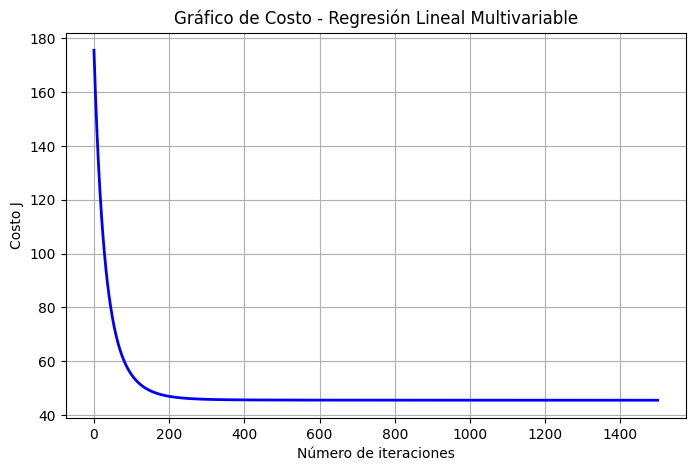

In [31]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1 # Evitar división por cero
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

# --- ENTRENAMIENTO LINEAL ---
# 1. Normalizamos X_train
X_train_norm, mu_lin, sigma_lin = featureNormalize(X_train)

# 2. Agregamos la columna de unos (término independiente x0)
X_train_ready = np.concatenate([np.ones((X_train.shape[0], 1)), X_train_norm], axis=1)

# 3. Hiperparámetros y ejecución
alpha_lin = 0.01
num_iters_lin = 1500
theta_lin = np.zeros(X_train_ready.shape[1])

theta_lin, J_history_lin = gradientDescentMulti(X_train_ready, y_train, theta_lin, alpha_lin, num_iters_lin)

# 4. Gráfico del Costo
plt.figure(figsize=(8,5))
plt.plot(np.arange(len(J_history_lin)), J_history_lin, 'b-', lw=2)
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Gráfico de Costo - Regresión Lineal Multivariable')
plt.grid(True)
plt.show()

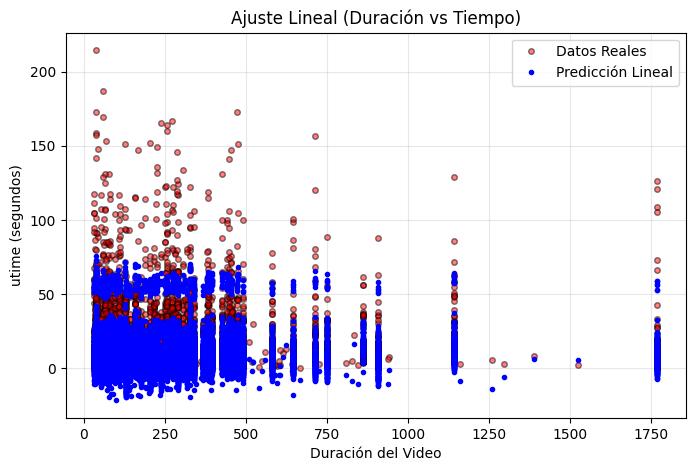

In [32]:
# === FUNCIÓN PLOT DATA ===
def plotData(x, y, xlabel, ylabel, titulo):
    # Grafica los puntos x e y en una figura nueva
    fig = plt.figure(figsize=(8, 5))
    plt.plot(x, y, 'ro', ms=4, mec='k', alpha=0.5, label='Datos Reales')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(titulo)

# === VISUALIZACIÓN 2D: LINEAL ===
# Usaremos la primera característica (Duración del video, X_test[:, 0]) para visualizar en 2D
plotData(X_test[:, 0], y_test, 'Duración del Video', 'utime (segundos)', 'Ajuste Lineal (Duración vs Tiempo)')

# Superponemos las predicciones del modelo lineal (en azul)
# Como es multivariable, usamos 'b.' (puntos azules) en lugar de '-' (línea continua)
plt.plot(X_test[:, 0], predicciones_lin, 'b.', label='Predicción Lineal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 2.1 Validación del Modelo Lineal (100 Predicciones)
Utilizamos nuestro conjunto de prueba (20%). Primero debemos normalizarlo usando los **mismos valores de media ($\mu$) y desviación estándar ($\sigma$) del entrenamiento**.
Luego, imprimimos 100 predicciones comparando el valor real del tiempo de transcodificación frente a lo que calcula nuestro algoritmo.

In [33]:
# Normalizar los datos de prueba usando mu y sigma del entrenamiento
X_test_norm = (X_test - mu_lin) / sigma_lin
X_test_ready = np.concatenate([np.ones((X_test.shape[0], 1)), X_test_norm], axis=1)

# Predicciones
predicciones_lin = np.dot(X_test_ready, theta_lin)

# Imprimir exactamente 100 predicciones de muestra
print("=== 100 PREDICCIONES: REGRESIÓN LINEAL MULTIVARIABLE ===")
print('{:>5s} | {:>10s} | {:>12s} | {:>12s}'.format('Video', 'Real (s)', 'Predicho (s)', 'Error (s)'))
print('-' * 50)
error_acumulado_lin = 0

for i in range(100):
    error = abs(y_test[i] - predicciones_lin[i])
    error_acumulado_lin += error
    print('{:5d} | {:10.2f} | {:12.2f} | {:12.2f}'.format(i+1, y_test[i], predicciones_lin[i], error))

print('-' * 50)
print(f"Error Promedio de estas 100 muestras: {error_acumulado_lin / 100:.2f} segundos\n")

=== 100 PREDICCIONES: REGRESIÓN LINEAL MULTIVARIABLE ===
Video |   Real (s) | Predicho (s) |    Error (s)
--------------------------------------------------
    1 |       6.08 |         8.74 |         2.65
    2 |       5.22 |         8.09 |         2.87
    3 |       4.10 |        10.32 |         6.22
    4 |       3.90 |         3.21 |         0.69
    5 |      41.39 |        26.18 |        15.21
    6 |       3.40 |         6.99 |         3.59
    7 |       4.41 |         6.77 |         2.37
    8 |      14.13 |        18.96 |         4.82
    9 |       0.35 |        -3.76 |         4.11
   10 |       2.68 |         7.92 |         5.24
   11 |       0.86 |        -8.43 |         9.29
   12 |       5.11 |        12.76 |         7.65
   13 |       3.66 |         3.67 |         0.01
   14 |      32.21 |        14.55 |        17.66
   15 |       2.24 |         1.31 |         0.93
   16 |      10.54 |        14.25 |         3.71
   17 |       7.87 |        10.05 |         2.17
   18 |   

## 3. Regresión Polinómica


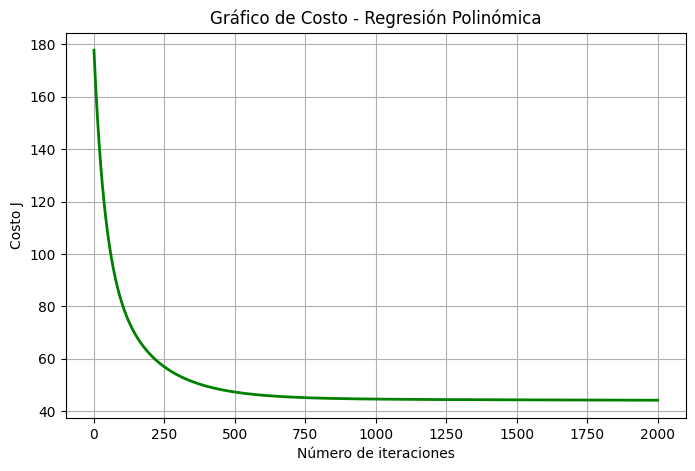

In [34]:
# --- ENTRENAMIENTO POLINÓMICO ---
# 1. Feature Engineering Manual (Concatenar X y X^2)
X_train_poly = np.concatenate([X_train, X_train * X_train], axis=1)

# 2. Normalizar la matriz polinómica
X_train_poly_norm, mu_poly, sigma_poly = featureNormalize(X_train_poly)

# 3. Agregar columna de unos
X_train_poly_ready = np.concatenate([np.ones((X_train.shape[0], 1)), X_train_poly_norm], axis=1)

# 4. Hiperparámetros (Alpha un poco menor para evitar inestabilidad con los cuadrados)
alpha_poly = 0.003
num_iters_poly = 2000
theta_poly = np.zeros(X_train_poly_ready.shape[1])

# Entrenamiento
theta_poly, J_history_poly = gradientDescentMulti(X_train_poly_ready, y_train, theta_poly, alpha_poly, num_iters_poly)

# Gráfico del Costo
plt.figure(figsize=(8,5))
plt.plot(np.arange(len(J_history_poly)), J_history_poly, 'g-', lw=2)
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Gráfico de Costo - Regresión Polinómica')
plt.grid(True)
plt.show()

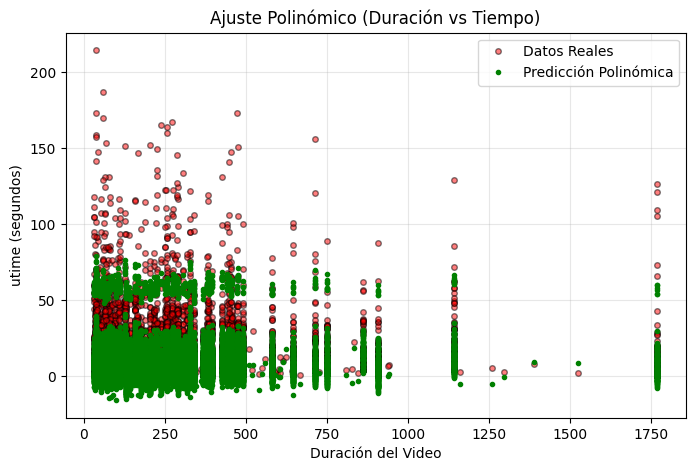

In [40]:
# === VISUALIZACIÓN 2D: POLINÓMICA ===
# Visualizamos la misma característica (Duración)
plotData(X_test[:, 0], y_test, 'Duración del Video', 'utime (segundos)', 'Ajuste Polinómico (Duración vs Tiempo)')

# Superponemos las predicciones del modelo polinómico (en verde)
plt.plot(X_test[:, 0], predicciones_poly, 'g.', label='Predicción Polinómica')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.1 Validación del Modelo Polinómico (100 Predicciones)
Para validar, aplicamos la misma transformación ($X^2$) al conjunto de prueba (20%) y normalizamos usando los $\mu$ y $\sigma$ polinómicos que calculamos en el entrenamiento.

In [35]:
# 1. Aplicar concatenación X^2 a los datos de prueba
X_test_poly = np.concatenate([X_test, X_test * X_test], axis=1)

# 2. Normalizar con estadísticos polinómicos de entrenamiento
X_test_poly_norm = (X_test_poly - mu_poly) / sigma_poly

# 3. Agregar unos
X_test_poly_ready = np.concatenate([np.ones((X_test.shape[0], 1)), X_test_poly_norm], axis=1)

# Predicciones
predicciones_poly = np.dot(X_test_poly_ready, theta_poly)

print("=== 100 PREDICCIONES: REGRESIÓN POLINÓMICA ===")
print('{:>5s} | {:>10s} | {:>12s} | {:>12s}'.format('Video', 'Real (s)', 'Predicho (s)', 'Error (s)'))
print('-' * 50)
error_acumulado_poly = 0

for i in range(100):
    error = abs(y_test[i] - predicciones_poly[i])
    error_acumulado_poly += error
    print('{:5d} | {:10.2f} | {:12.2f} | {:12.2f}'.format(i+1, y_test[i], predicciones_poly[i], error))

print('-' * 50)
print(f"Error Promedio de estas 100 muestras: {error_acumulado_poly / 100:.2f} segundos\n")

=== 100 PREDICCIONES: REGRESIÓN POLINÓMICA ===
Video |   Real (s) | Predicho (s) |    Error (s)
--------------------------------------------------
    1 |       6.08 |         8.79 |         2.70
    2 |       5.22 |         6.89 |         1.67
    3 |       4.10 |        10.09 |         5.99
    4 |       3.90 |         2.53 |         1.37
    5 |      41.39 |        25.67 |        15.72
    6 |       3.40 |         6.39 |         2.99
    7 |       4.41 |         6.65 |         2.24
    8 |      14.13 |        19.39 |         5.26
    9 |       0.35 |        -4.03 |         4.38
   10 |       2.68 |         6.71 |         4.04
   11 |       0.86 |        -6.68 |         7.54
   12 |       5.11 |        12.50 |         7.39
   13 |       3.66 |         3.75 |         0.09
   14 |      32.21 |        17.34 |        14.86
   15 |       2.24 |         0.91 |         1.33
   16 |      10.54 |        13.20 |         2.66
   17 |       7.87 |         9.08 |         1.21
   18 |       1.92 |

## 4. Ecuación de la Normal


In [36]:
def normalEqn(X, y):
    theta = np.zeros(X.shape[1])
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T,X)),X.T),y)
    return theta

# --- ENTRENAMIENTO NORMAL ---
# Usamos los datos crudos (sin normalizar), solo añadimos la columna de unos
X_train_normal = np.concatenate([np.ones((X_train.shape[0], 1)), X_train], axis=1)

theta_normal = normalEqn(X_train_normal, y_train)
print("Theta calculado exitosamente mediante la Ecuación de la Normal.\n")

# --- VALIDACIÓN NORMAL (100 Predicciones) ---
X_test_normal = np.concatenate([np.ones((X_test.shape[0], 1)), X_test], axis=1)
predicciones_normal = np.dot(X_test_normal, theta_normal)

print("=== 100 PREDICCIONES: ECUACIÓN DE LA NORMAL ===")
print('{:>5s} | {:>10s} | {:>12s} | {:>12s}'.format('Video', 'Real (s)', 'Predicho (s)', 'Error (s)'))
print('-' * 50)
error_acumulado_normal = 0

for i in range(100):
    error = abs(y_test[i] - predicciones_normal[i])
    error_acumulado_normal += error
    print('{:5d} | {:10.2f} | {:12.2f} | {:12.2f}'.format(i+1, y_test[i], predicciones_normal[i], error))

print('-' * 50)
print(f"Error Promedio de estas 100 muestras: {error_acumulado_normal / 100:.2f} segundos\n")

Theta calculado exitosamente mediante la Ecuación de la Normal.

=== 100 PREDICCIONES: ECUACIÓN DE LA NORMAL ===
Video |   Real (s) | Predicho (s) |    Error (s)
--------------------------------------------------
    1 |       6.08 |         8.44 |         2.36
    2 |       5.22 |        12.07 |         6.86
    3 |       4.10 |        17.21 |        13.11
    4 |       3.90 |         3.98 |         0.08
    5 |      41.39 |        16.89 |        24.50
    6 |       3.40 |         5.45 |         2.04
    7 |       4.41 |        12.94 |         8.54
    8 |      14.13 |        17.31 |         3.18
    9 |       0.35 |         8.62 |         8.27
   10 |       2.68 |        15.70 |        13.03
   11 |       0.86 |        -3.47 |         4.34
   12 |       5.11 |        13.85 |         8.74
   13 |       3.66 |         9.28 |         5.61
   14 |      32.21 |         6.36 |        25.84
   15 |       2.24 |         1.22 |         1.02
   16 |      10.54 |        16.11 |         5.57
   

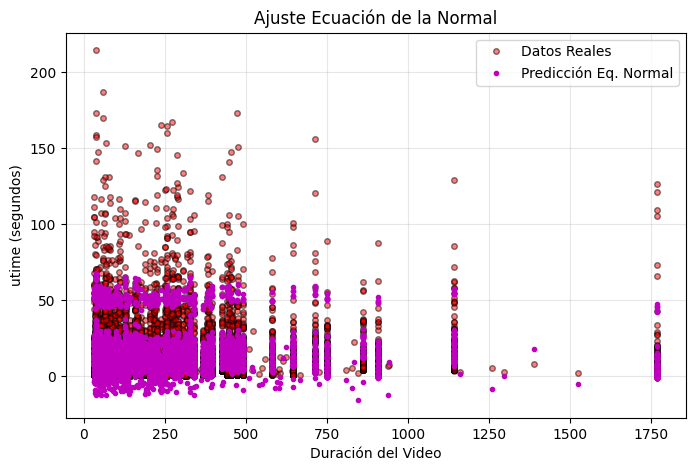

In [37]:
# === VISUALIZACIÓN 2D: ECUACIÓN DE LA NORMAL ===
# Visualizamos la misma característica (Duración)
plotData(X_test[:, 0], y_test, 'Duración del Video', 'utime (segundos)', 'Ajuste Ecuación de la Normal')

# Superponemos las predicciones de la ecuación normal (en morado)
plt.plot(X_test[:, 0], predicciones_normal, 'm.', label='Predicción Eq. Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Efectividad en el 20% de Prueba
Calculamos el **Error RMSE (Raíz del Error Cuadrático Medio)** pero usando TODO el conjunto de prueba (no solo los 100 impresos) para evaluar la efectividad total del modelo con datos que nunca ha visto antes.

In [38]:
# Calcular RMSE en TODO el conjunto de prueba (20% del total)
rmse_lin = np.sqrt(np.mean(np.square(predicciones_lin - y_test)))
rmse_poly = np.sqrt(np.mean(np.square(predicciones_poly - y_test)))
rmse_normal = np.sqrt(np.mean(np.square(predicciones_normal - y_test)))

print("="*50)
print(" COMPARATIVA GLOBAL DE EFECTIVIDAD (RMSE) ")
print(" Evaluado sobre todos los datos de prueba")
print("="*50)
print(f"1. Modelo Lineal (Gradiente) : {rmse_lin:.2f} segundos de error")
print(f"2. Modelo Polinómico         : {rmse_poly:.2f} segundos de error")
print(f"3. Ecuación de la Normal     : {rmse_normal:.2f} segundos de error")
print("="*50)

 COMPARATIVA GLOBAL DE EFECTIVIDAD (RMSE) 
 Evaluado sobre todos los datos de prueba
1. Modelo Lineal (Gradiente) : 9.31 segundos de error
2. Modelo Polinómico         : 9.15 segundos de error
3. Ecuación de la Normal     : 11.02 segundos de error


## 5. Comparativa Final y Gráfica de Efectividad (100 Predicciones)
Para concluir, consolidamos los resultados de los tres modelos evaluados.
Calcularemos el **Error Absoluto Medio (MAE)** específicamente sobre las primeras 100 predicciones de nuestro conjunto de prueba.

Adicionalmente, se presenta una gráfica comparativa donde la línea negra representa el **tiempo real** de transcodificación, y las líneas punteadas representan los intentos de cada algoritmo por predecir dicho tiempo. El modelo que más se acerque a la línea negra será el más efectivo.

Valor real utime fila 0: 6.084 segundos

=== Comparativa de los 3 modelos (primeras 10 predicciones) ===
   Ej  Real (s)   GD Lineal GD Polinomial  Ec. Normal
-------------------------------------------------------
    1     6.084       8.735         8.786       8.440
    2     5.216       8.087         6.886      12.071
    3     4.100      10.315        10.093      17.215
    4     3.900       3.209         2.533       3.985
    5    41.387      26.178        25.668      16.887
    6     3.404       6.994         6.394       5.447
    7     4.408       6.774         6.646      12.945
    8    14.133      18.956        19.395      17.312
    9     0.348      -3.762        -4.031       8.620
   10     2.676       7.921         6.712      15.703

=== Error Absoluto Medio (MAE) sobre 100 predicciones ===
  Descenso por el Gradiente (lineal):  5.4662 segundos
  Regresión Polinomial:                5.2635 segundos
  Ecuación Normal:                     7.4517 segundos


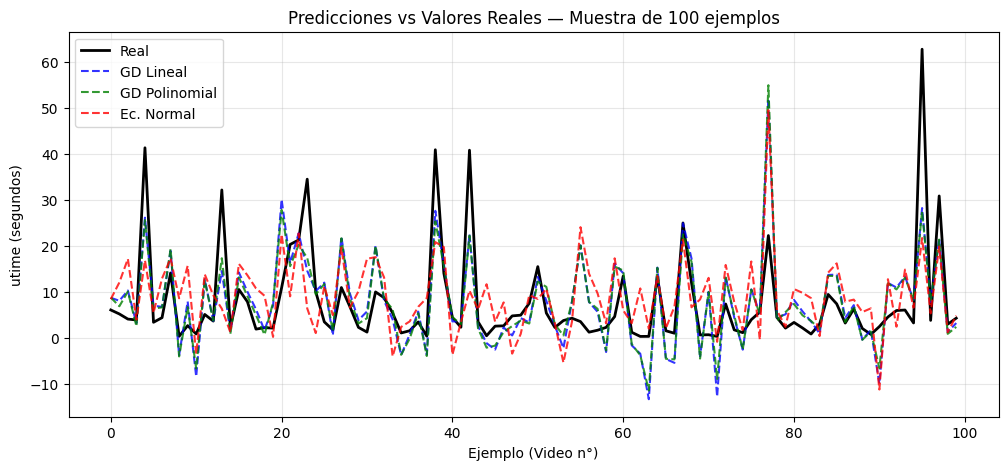

In [39]:
# 1. Calculamos el Error Absoluto Medio (MAE) sobre las primeras 100 predicciones
error_medio_gd = np.mean(np.abs(predicciones_lin[:100] - y_test[:100]))
error_medio_poly = np.mean(np.abs(predicciones_poly[:100] - y_test[:100]))
error_medio_ne = np.mean(np.abs(predicciones_normal[:100] - y_test[:100]))

# 2. Imprimimos el valor real del primer video como referencia
y_real_0 = y_test[0]
print('Valor real utime fila 0:', y_real_0, 'segundos\n')

# 3. Tabla comparativa de las primeras 10 predicciones
print('=== Comparativa de los 3 modelos (primeras 10 predicciones) ===')
print('{:>5s}{:>10s}{:>12s}{:>14s}{:>12s}'.format('Ej', 'Real (s)', 'GD Lineal', 'GD Polinomial', 'Ec. Normal'))
print('-' * 55)
for i in range(10):
    print('{:>5d}{:>10.3f}{:>12.3f}{:>14.3f}{:>12.3f}'.format(
        i+1,
        y_test[i],
        predicciones_lin[i],
        predicciones_poly[i],
        predicciones_normal[i]
    ))

print('\n=== Error Absoluto Medio (MAE) sobre 100 predicciones ===')
print('  Descenso por el Gradiente (lineal):  {:.4f} segundos'.format(error_medio_gd))
print('  Regresión Polinomial:                {:.4f} segundos'.format(error_medio_poly))
print('  Ecuación Normal:                     {:.4f} segundos'.format(error_medio_ne))

# 4. Gráfica comparativa de 100 ejemplos
plt.figure(figsize=(12, 5))
indices = np.arange(100) # Creamos un array del 0 al 99 para el eje X

# Graficamos los datos reales y las 3 predicciones limitando a los primeros 100 datos [:100]
plt.plot(indices, y_test[:100], 'k-', lw=2, label='Real')
plt.plot(indices, predicciones_lin[:100], 'b--', lw=1.5, alpha=0.8, label='GD Lineal')
plt.plot(indices, predicciones_poly[:100], 'g--', lw=1.5, alpha=0.8, label='GD Polinomial')
plt.plot(indices, predicciones_normal[:100], 'r--', lw=1.5, alpha=0.8, label='Ec. Normal')

plt.xlabel('Ejemplo (Video n°)')
plt.ylabel('utime (segundos)')
plt.title('Predicciones vs Valores Reales — Muestra de 100 ejemplos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()